In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
 
print("Loaded Basic Libraries...")

Loaded Basic Libraries...


In [2]:
file_path = r"C:\Users\saira\Projects\Netflix-recommendation-engine\data\combined_data_1.txt"

if os.path.exists(file_path):
    print("File Found! Data loading... ")
    
    # Corrected Loading: Netflix data has 3 columns (Cust_Id, Rating, Date)
    
    netflix_dataset = pd.read_csv(file_path, header=None, names=['Cust_Id', 'Rating'], usecols=[0,1])
    
    print("Data loaded successfully! ")

    # 1. Convert Rating to float (Crucial for NaN detection)
    netflix_dataset['Rating'] = pd.to_numeric(netflix_dataset['Rating'], errors='coerce')

    # 2. Find NaNs (These are our Movie ID headers like '1:', '2:', etc.)
    df_nan = netflix_dataset[pd.isnull(netflix_dataset['Rating'])].reset_index()

    # DEBUG CHECK: If this prints 0, your data loading is completely wrong.
    print(f"Movie Headers (NaNs) found: {len(df_nan)}")

    if len(df_nan) > 0:
        # 3. Pre-allocate NumPy array for Speed 
        movie_np = np.empty(len(netflix_dataset))

        # 4. Fill Movie IDs
        for i in range(len(df_nan) - 1):
            start = df_nan.iloc[i]['index']
            end = df_nan.iloc[i+1]['index']
            movie_np[start:end] = i + 1

        # Handle last movie
        last_start = df_nan.iloc[-1]['index']
        movie_np[last_start:] = len(df_nan)

        # 5. Add Movie_Id column to the FULL dataset
        netflix_dataset['Movie_Id'] = movie_np.astype(int)

        # 6. Drop the Movie Header rows (where Rating is NaN)
        netflix_dataset = netflix_dataset[pd.notnull(netflix_dataset['Rating'])]

        # 7. Convert columns to proper types
        netflix_dataset['Cust_Id'] = netflix_dataset['Cust_Id'].astype(int)
        netflix_dataset['Rating'] = netflix_dataset['Rating'].astype(float)

        print("Data Cleaning Successfull")
        print(netflix_dataset.head())
    else:
        print(" ERROR: No Movie IDs (NaNs) found. Check your file format!")

else:
    print("File Not Found!! Check your path.")

File Found! Data loading... 
Data loaded successfully! 
Movie Headers (NaNs) found: 4499
Data Cleaning Successfull
   Cust_Id  Rating  Movie_Id
1  1488844     3.0         1
2   822109     5.0         1
3   885013     4.0         1
4    30878     4.0         1
5   823519     3.0         1


In [3]:

user_counts = netflix_dataset.groupby('Cust_Id')['Rating'].count()


movie_counts = netflix_dataset.groupby('Movie_Id')['Rating'].count()


drop_user_list = user_counts[user_counts < 50].index
drop_movie_list = movie_counts[movie_counts < 1000].index


netflix_dataset = netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_user_list)]
netflix_dataset = netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_list)]

print(f"Final Shape After Data Filtering: {netflix_dataset.shape}")

Final Shape After Data Filtering: (17997304, 3)


In [4]:
from scipy.sparse import csr_matrix

# Pivot table creation using Sparse Matrix logic

df_p = netflix_dataset.pivot_table(index='Cust_Id', columns='Movie_Id', values='Rating')


sparse_matrix = csr_matrix(df_p.fillna(0).values)

In [5]:
# conda install -c conda-forge scikit-surprise --no-update-deps

In [6]:
# 1. Take a subset 

netflix_subset = netflix_dataset.iloc[:100000, :] 

# 2. Create Pivot Table
movie_matrix = netflix_subset.pivot_table(index='Cust_Id', columns='Movie_Id', values='Rating')

# 3. Specific Movie Recommendation (Example: Movie ID 28)
target_movie_ratings = movie_matrix[28]
similar_to_target = movie_matrix.corrwith(target_movie_ratings)

# 4. Filter out movies with low correlation
corr_target = pd.DataFrame(similar_to_target, columns=['Correlation'])
corr_target.dropna(inplace=True)
print(corr_target.sort_values('Correlation', ascending=False).head(10))

          Correlation
Movie_Id             
28           1.000000
5            0.316857
26           0.252942
16           0.246729
24           0.227926
30           0.215880
17           0.213177
18           0.210859
25           0.183897
3            0.131166


In [7]:
# import numpy as np
from scipy.sparse.linalg import svds


df_pivot = netflix_dataset.head(10000).pivot_table(index='Cust_Id', columns='Movie_Id', values='Rating').fillna(0)


R = df_pivot.values
user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

# 3. SVD apply  (k=50 ---- 50 latent features)
U, sigma, Vt = svds(R_demeaned, k=min(50, R_demeaned.shape[1]-1))
sigma = np.diag(sigma)

# 4. Multiply back to get Predictions
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)
preds_df = pd.DataFrame(all_user_predicted_ratings, columns=df_pivot.columns, index=df_pivot.index)

print("SVD Predictions Ready! ✅")
print(preds_df.head())

SVD Predictions Ready! ✅
Movie_Id             3             5             6    8
Cust_Id                                                
7         2.464695e-14  3.952394e-14  2.442491e-14  5.0
695       3.802514e-15  1.182388e-14  1.018630e-14  1.0
1333      4.000000e+00  2.908784e-14  3.019807e-14  3.0
1983      2.842171e-14  2.775558e-14  2.753353e-14  3.0
2133      1.915135e-14  1.865175e-14  1.854072e-14  2.0


In [8]:

titles_path = r"C:\Users\saira\Projects\Netflix-recommendation-engine\data\movie_titles _1_.csv"

try:
    # Netflix titles format: Movie_Id, Year, Name
    movie_titles = pd.read_csv(titles_path, 
                               encoding="latin1", 
                               header=None, 
                               names=['Movie_Id', 'Year', 'Name'], 
                               on_bad_lines='skip') # Bad formatting unte skip chestundi

    movie_titles.set_index('Movie_Id', inplace=True)
    print("Movie Titles loaded Successfully...")
    print(movie_titles.head(10))
    
except FileNotFoundError:
    print(" Error: File not found")
except Exception as e:
    print(f" Error: {e}")

Movie Titles loaded Successfully...
            Year                          Name
Movie_Id                                      
1         2003.0               Dinosaur Planet
2         2004.0    Isle of Man TT 2004 Review
3         1997.0                     Character
4         1994.0  Paula Abdul's Get Up & Dance
5         2004.0      The Rise and Fall of ECW
6         1997.0                          Sick
7         1992.0                         8 Man
8         2004.0    What the #$*! Do We Know!?
9         1991.0      Class of Nuke 'Em High 2
10        2001.0                       Fighter


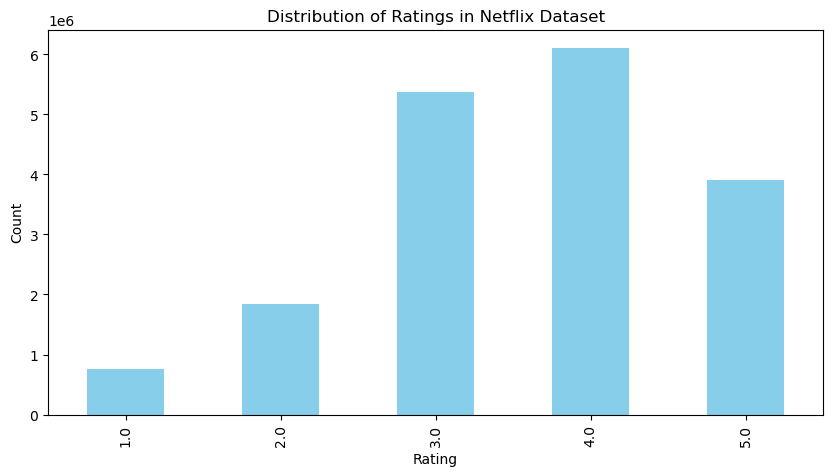

Top 10 Most Rated Movies:
Movie_Id
1905    Pirates of the Caribbean: The Curse of the Bla...
2452        Lord of the Rings: The Fellowship of the Ring
4306                                      The Sixth Sense
571                                       American Beauty
3860                                       Bruce Almighty
2862                             The Silence of the Lambs
3962                            Finding Nemo (Widescreen)
4432                                      The Italian Job
3938                                              Shrek 2
2782                                           Braveheart
Name: Name, dtype: object


In [9]:
import matplotlib.pyplot as plt

# 1. Rating distribution 
plt.figure(figsize=(10,5))
netflix_dataset['Rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Ratings in Netflix Dataset')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# 2. Most rated movies (Popularity check)
top_movies = netflix_dataset.groupby('Movie_Id')['Rating'].count().sort_values(ascending=False).head(10)
top_movies_with_names = top_movies.to_frame().join(movie_titles)['Name']
print("Top 10 Most Rated Movies:")
print(top_movies_with_names)

In [10]:
def recommend_user_movies(user_id, num_recommendations=5):
    # 1. Find the user's row in the pivot table
    user_row_number = df_pivot.index.get_loc(user_id)
    
    # 2. Get predictions for this user from our SVD preds_df
    sorted_user_predictions = preds_df.iloc[user_row_number].sort_values(ascending=False)
    
    # 3. Create a DataFrame for recommendations
    recommendations = (
        pd.DataFrame(sorted_user_predictions)
        .reset_index()
        .merge(movie_titles, on='Movie_Id')
        .rename(columns={user_id: 'Predictions'})
    )
    
    return recommendations.head(num_recommendations)

print("Function defined successfully! ")

Function defined successfully! 


In [11]:
# Edhaina oka user ID ni pick chey (df_pivot index nundi)
user_to_check = df_pivot.index[5] 
print(f"Recommendations for User {user_to_check}:")
print(recommend_user_movies(user_to_check))

Recommendations for User 3184:
   Movie_Id   Predictions    Year                        Name
0         8  2.000000e+00  2004.0  What the #$*! Do We Know!?
1         3  1.915135e-14  1997.0                   Character
2         5  1.865175e-14  2004.0    The Rise and Fall of ECW
3         6  1.854072e-14  1997.0                        Sick


In [12]:
# 1. First, calculate the counts (This creates the 'top_10_popular' variable)
movie_counts = netflix_dataset.groupby('Movie_Id')['Rating'].count().sort_values(ascending=False)

# 2. Join with movie_titles to get names
top_10_popular = movie_counts.head(10).to_frame().join(movie_titles)

print("Variable 'top_10_popular' is now ready! ✅")
print(top_10_popular[['Name', 'Rating']]) # Check results

Variable 'top_10_popular' is now ready! ✅
                                                       Name  Rating
Movie_Id                                                           
1905      Pirates of the Caribbean: The Curse of the Bla...  120051
2452          Lord of the Rings: The Fellowship of the Ring  104879
4306                                        The Sixth Sense  104385
571                                         American Beauty  103642
3860                                         Bruce Almighty  100812
2862                               The Silence of the Lambs   96739
3962                              Finding Nemo (Widescreen)   96217
4432                                        The Italian Job   96152
3938                                                Shrek 2   95079
2782                                             Braveheart   93299


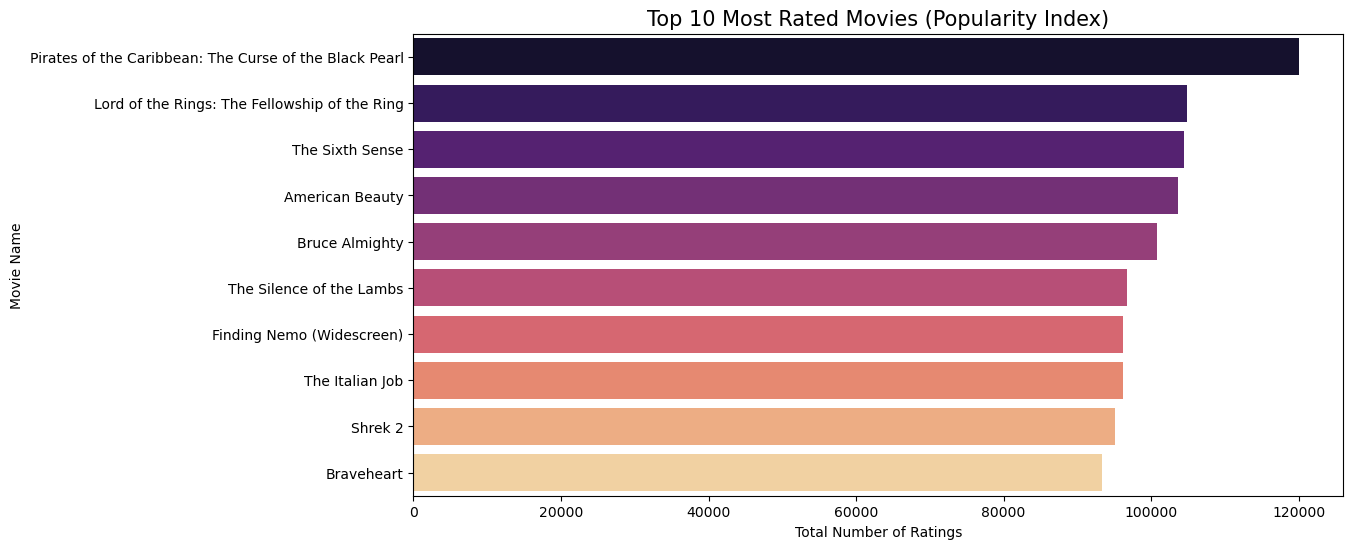

In [13]:
# Updated Plotting Code (No Warnings)
plt.figure(figsize=(12,6))

# Fix: Assign 'Name' to 'hue' and set legend=False
sns.barplot(
    x=top_10_popular['Rating'], 
    y=top_10_popular['Name'], 
    hue=top_10_popular['Name'], 
    palette='magma', 
    legend=False
)

plt.title('Top 10 Most Rated Movies (Popularity Index)', fontsize=15)
plt.xlabel('Total Number of Ratings')
plt.ylabel('Movie Name')
plt.show()

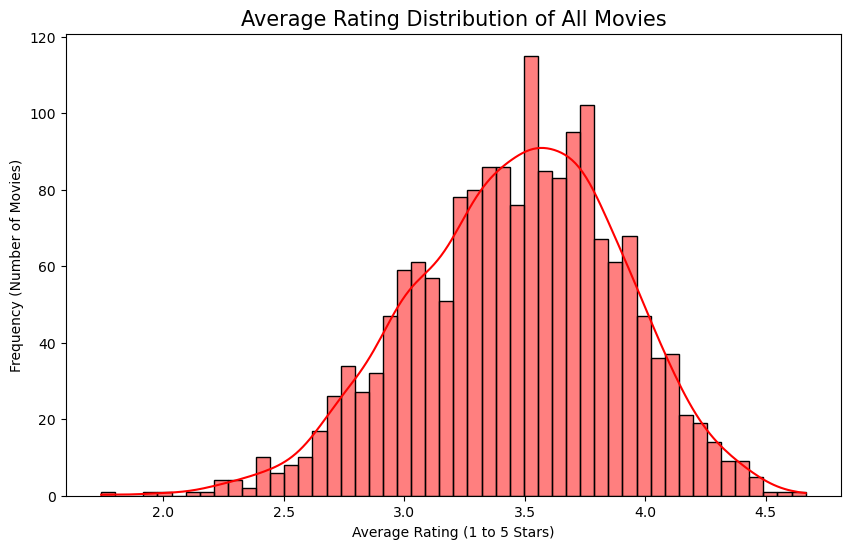

In [14]:
# 1. Calculate average rating for each movie
movie_avg_rating = netflix_dataset.groupby('Movie_Id')['Rating'].mean()

# 2. Plot the distribution
plt.figure(figsize=(10,6))
sns.histplot(movie_avg_rating, bins=50, kde=True, color='red')
plt.title('Average Rating Distribution of All Movies', fontsize=15)
plt.xlabel('Average Rating (1 to 5 Stars)')
plt.ylabel('Frequency (Number of Movies)')
plt.show()

In [15]:
import pickle

# 1. We need the Pivot Table (to know User-Movie links)
# 2. We need the preds_df (The actual predictions we calculated)

data_to_save = {
    'pivot_table': df_pivot,
    'predictions': preds_df,
    'movie_titles': movie_titles
}

# Save everything into a single Pickle file
with open('movie_recommender.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print("Model saved successfully as movie_recommender.pkl! ✅")

Model saved successfully as movie_recommender.pkl! ✅
